# Lab 1 - MNIST CNN: Gradient vs Cập nhật Parabol

Notebook này minh họa 2 cách cập nhật tham số cho mạng CNN trên MNIST:
1. **Gradient Descent thủ công** (backpropagation + SGD tự cài đặt) — theo dõi train/val/test.
2. **Phương pháp Parabol** (không dùng backward/gradient) — nội suy bậc 2 trên hướng ngẫu nhiên, theo dõi train/val/test.

**Tập dữ liệu:**
- Train: 54,000 mẫu (90% của 60,000)
- Validation: 6,000 mẫu (10% của 60,000) — dùng để theo dõi quá trình học, phát hiện overfitting
- Test: 10,000 mẫu — đánh giá cuối cùng, **không** dùng trong huấn luyện


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiet bi dang dung:", device)


Thiet bi dang dung: cpu


## Tải dữ liệu MNIST và tạo DataLoader

Chia tập train gốc (60,000 mẫu) thành:
- **train_dataset** (54,000): dùng để cập nhật tham số mạng
- **val_dataset** (6,000): dùng để theo dõi hiệu quả học mà **không** tác động vào tham số

> Validation giúp phát hiện **overfitting**: nếu train_loss giảm nhưng val_loss tăng → mạng đang học thuộc lòng dữ liệu.


In [ ]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tải toàn bộ tập train gốc (60,000 mẫu) và tập test (10,000 mẫu)
full_train_dataset = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# --- Chia train/validation ---
# 90% dùng để train, 10% dùng làm validation
# random_split dùng seed cố định để kết quả tái hiện được
val_size   = int(0.1 * len(full_train_dataset))   # 6,000 mẫu
train_size = len(full_train_dataset) - val_size    # 54,000 mẫu
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)  # seed đã khai báo ở cell trên
)

common_batch_size = 256

# DataLoader cho Gradient Method
train_loader = DataLoader(train_dataset, batch_size=common_batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=common_batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=common_batch_size, shuffle=False, num_workers=0)

# DataLoader cho Parabola Method (dùng cùng split để so sánh công bằng)
parabola_train_loader = DataLoader(train_dataset, batch_size=common_batch_size, shuffle=True,  num_workers=0)
parabola_val_loader   = DataLoader(val_dataset,   batch_size=common_batch_size, shuffle=False, num_workers=0)

print(f"Số mẫu train   : {len(train_dataset):,}")
print(f"Số mẫu val     : {len(val_dataset):,}")
print(f"Số mẫu test    : {len(test_dataset):,}")
print(f"Batch size     : {common_batch_size}")
print(f"Số batch/epoch : {len(train_loader)} (train), {len(val_loader)} (val)")


Số mẫu train   : 54,000
Số mẫu val     : 6,000
Số mẫu test    : 10,000
Batch size     : 256
Số batch/epoch : 211 (train), 24 (val)


## Xem nhanh một vài mẫu MNIST
Cell này hiển thị 8 ảnh đầu tiên của một mini-batch để kiểm tra dữ liệu đã được đọc đúng.


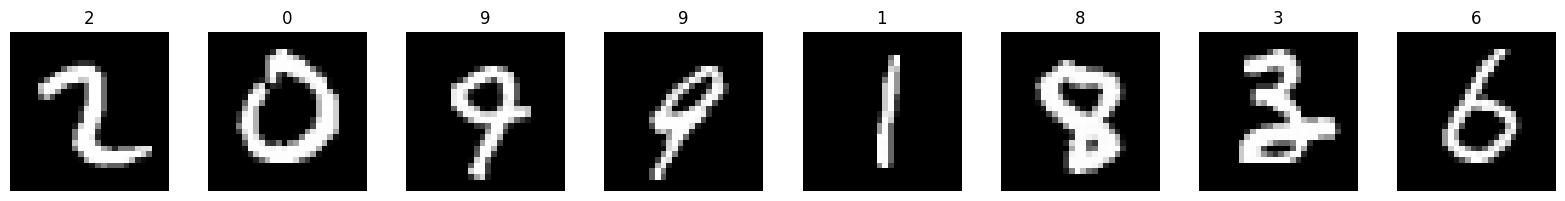

In [3]:
images, labels = next(iter(train_loader))
images = images[:8]
labels = labels[:8]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze().numpy(), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Định nghĩa mô hình CNN

Kiến trúc `SimpleCNN` xử lý ảnh đầu vào kích thước $1 \times 28 \times 28$ qua các bước sau:

**Khối `self.features` — trích xuất đặc trưng:**

| Layer | Công thức kích thước output | Code tương ứng |
|-------|-----------------------------|----------------|
| Conv2d(1→16, k=3, p=1) | $16 \times 28 \times 28$ | `nn.Conv2d(1, 16, kernel_size=3, padding=1)` |
| ReLU | $16 \times 28 \times 28$ (giữ nguyên, âm→0) | `nn.ReLU()` |
| MaxPool2d(2) | $16 \times 14 \times 14$ | `nn.MaxPool2d(2)` |
| Conv2d(16→32, k=3, p=1) | $32 \times 14 \times 14$ | `nn.Conv2d(16, 32, kernel_size=3, padding=1)` |
| ReLU | $32 \times 14 \times 14$ | `nn.ReLU()` |
| MaxPool2d(2) | $32 \times 7 \times 7$ | `nn.MaxPool2d(2)` |

**Khối `self.classifier` — phân loại:**

| Layer | Công thức | Code tương ứng |
|-------|-----------|----------------|
| Flatten | $32 \times 7 \times 7 = 1568$ chiều | `nn.Flatten()` |
| Linear(1568→64) + ReLU | $h = \text{ReLU}(W_1 x + b_1)$, $W_1 \in \mathbb{R}^{64 \times 1568}$ | `nn.Linear(32*7*7, 64)` |
| Linear(64→10) | $z = W_2 h + b_2$, $z \in \mathbb{R}^{10}$ (logits) | `nn.Linear(64, 10)` |

Output cuối là **logits** $z \in \mathbb{R}^{10}$ — chưa qua softmax, mỗi giá trị tương ứng một chữ số 0–9.

Tổng tham số cần học: $\theta = \{W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}, W_1, b_1, W_2, b_2, \ldots\}$


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Hàm huấn luyện và đánh giá — Phương pháp Gradient Descent

---

### `cross_entropy_from_logits(logits, targets)`

Tính Cross-Entropy Loss từ logits (chưa qua softmax):

$$
L_B = \frac{1}{|B|} \sum_{i \in B} \left[ \underbrace{\log \sum_{k=0}^{9} e^{z_k^{(i)}}}_{\texttt{logsumexp}} - \underbrace{z_{y_i}^{(i)}}_{\texttt{logit của nhãn đúng}} \right]
$$

Trong code: `logits.gather(1, targets.unsqueeze(1)).squeeze(1)` lấy đúng $z_{y_i}$ cho mỗi mẫu $i$.

---

### `evaluate(model, loader, loss_fn)`

Tính loss và accuracy trên toàn bộ loader mà **không cập nhật tham số**:

$$
\text{avg\_loss} = \frac{\sum_{i} L_i \cdot |B_i|}{\sum_{i} |B_i|}, \qquad \text{accuracy} = \frac{\text{số mẫu dự đoán đúng}}{\text{tổng số mẫu}}
$$

Dự đoán đúng khi: $\hat{y} = \arg\max_k z_k = y$ (nhãn thật).

---

### `manual_gradient_descent_step(model, lr)`

Cập nhật **thủ công** theo SGD cơ bản — không dùng `optim.SGD`:

$$
\theta \leftarrow \theta - \eta \cdot \underbrace{\frac{\partial L_B}{\partial \theta}}_{\texttt{p.grad}}
$$

Tương đương code: `p -= lr * p.grad` với `lr` = $\eta = 0.01$.

---

### `train_one_epoch_gradient(model, loader, loss_fn, lr)`

Luồng xử lý mỗi mini-batch (kích thước 256):

$$
\underbrace{z = f(x;\theta)}_{\text{(1) forward}} \;\longrightarrow\; \underbrace{L_B = \frac{1}{256}\sum \ell(z_i, y_i)}_{\text{(2) loss}} \;\longrightarrow\; \underbrace{\frac{\partial L_B}{\partial \theta}}_{\text{(3) backward (chain rule)}} \;\longrightarrow\; \underbrace{\theta \leftarrow \theta - 0.01 \cdot \nabla_\theta L_B}_{\text{(4) cập nhật}}
$$

> **Tại sao `zero_grad()` trước backward?**  
> PyTorch mặc định **cộng dồn** gradient: `p.grad += ∂L/∂p`.  
> Nếu không gọi `zero_grad()`, gradient của batch này sẽ cộng thêm vào gradient batch trước → sai công thức.


In [5]:
def cross_entropy_from_logits(logits, targets):
    """
    Tự cài đặt Cross-Entropy Loss từ logits (chưa qua softmax).

    Công thức:
        CE = mean( logsumexp(logits) − logit[true_class] )

    Tại sao dùng logsumexp thay vì log(sum(exp(...))):
        → Tránh tràn số (overflow) khi logit lớn.
        logsumexp(z) = log( Σ exp(z_i) )  nhưng tính ổn định số hơn.

    Ví dụ với 1 mẫu, logits = [0.1, 2.3, 0.5], true_class = 1:
        logsumexp = log(e^0.1 + e^2.3 + e^0.5) ≈ 2.49
        CE = 2.49 − 2.3 = 0.19  (loss thấp vì dự đoán đúng)
    """
    logsumexp = torch.logsumexp(logits, dim=1)                          # (batch,)
    true_class_logits = logits.gather(1, targets.unsqueeze(1)).squeeze(1)  # lấy logit của nhãn đúng
    return (logsumexp - true_class_logits).mean()                       # trung bình trên batch


def evaluate(model, loader, loss_fn):
    """
    Đánh giá mô hình trên một DataLoader (dùng cho cả val lẫn test).

    Chế độ model.eval():
        - Tắt Dropout (nếu có): dùng toàn bộ neurons
        - Tắt BatchNorm tracking: dùng running stats thay vì batch stats
        - torch.no_grad(): không tính gradient → tiết kiệm bộ nhớ & nhanh hơn

    Returns:
        avg_loss : loss trung bình trên tất cả mẫu (weighted by batch size)
        accuracy : tỉ lệ dự đoán đúng
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)                                # forward, không tính gradient
            loss = loss_fn(logits, y)

            total_loss    += loss.item() * x.size(0)        # nhân với batch size để tính trung bình đúng
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def manual_gradient_descent_step(model, lr):
    """
    Cập nhật tham số bằng SGD thủ công (không dùng optim.SGD của PyTorch).

    Công thức Gradient Descent:
        θ_new = θ_old − lr × ∂L/∂θ

    Tại sao @torch.no_grad():
        → Đảm bảo phép gán p -= lr * p.grad không được PyTorch theo dõi
          (tránh tạo graph tính toán không cần thiết).

    Lưu ý: p.grad được PyTorch điền vào sau khi gọi loss.backward().
    """
    for p in model.parameters():
        if p.grad is not None:
            p -= lr * p.grad   # w ← w − lr * ∂L/∂w


def train_one_epoch_gradient(model, loader, loss_fn, lr):
    """
    Huấn luyện 1 epoch với Gradient Descent thủ công.

    Luồng xử lý mỗi mini-batch:
    ┌─────────────────────────────────────────────────────────┐
    │ 1. zero_grad()   → xóa gradient cũ (tránh cộng dồn)   │
    │ 2. forward       → logits = model(x)                   │
    │ 3. loss          → CE(logits, y)                       │
    │ 4. backward()    → tính ∂L/∂w cho tất cả tham số      │
    │ 5. manual step   → w ← w − lr * ∂L/∂w                 │
    └─────────────────────────────────────────────────────────┘

    Returns:
        avg_loss : loss trung bình trên toàn epoch
        accuracy : accuracy trên toàn epoch
    """
    model.train()   # bật chế độ training (Dropout, BN hoạt động bình thường)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Bước 1: Xóa gradient cũ — nếu không xóa, gradient sẽ cộng dồn (PyTorch mặc định +=)
        model.zero_grad(set_to_none=True)

        # Bước 2 & 3: Forward + tính loss
        logits = model(x)
        loss = loss_fn(logits, y)

        # Bước 4: Backward — lan truyền ngược, tính ∂L/∂w bằng chain rule
        loss.backward()

        # Bước 5: Cập nhật tham số theo hướng ngược gradient
        manual_gradient_descent_step(model, lr)

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN — Phương pháp Gradient Descent 

**Công thức cập nhật mỗi mini-batch** (`lr_grad = 0.01`, batch size = 256):

$$
\theta_{t+1} = \theta_t - 0.01 \cdot \nabla_{\theta} L_B(\theta_t)
$$

Viết tường minh cho từng lớp:

$$
W^{(l)}_{t+1} = W^{(l)}_t - 0.01 \cdot \frac{\partial L_B}{\partial W^{(l)}}, \qquad b^{(l)}_{t+1} = b^{(l)}_t - 0.01 \cdot \frac{\partial L_B}{\partial b^{(l)}}
$$

**Cấu hình training:**
- `epochs_grad = 10` → lặp qua 54,000 mẫu train × 10 lần
- Mỗi epoch có $\lceil 54000/256 \rceil = 211$ bước cập nhật
- Tổng số lần cập nhật: $211 \times 10 = 2110$ bước

**Theo dõi 3 split sau mỗi epoch:**

| Biến | Công thức | Ý nghĩa |
|------|-----------|---------|
| `train_loss` | $\frac{1}{54000}\sum_{i \in \text{train}} \ell_i$ | Mạng học tốt trên dữ liệu đã thấy chưa? |
| `val_loss` | $\frac{1}{6000}\sum_{i \in \text{val}} \ell_i$ | Tổng quát hóa ra ngoài dữ liệu train chưa? |
| `test_loss` | $\frac{1}{10000}\sum_{i \in \text{test}} \ell_i$ | Hiệu năng thực tế (chỉ quan sát, không điều chỉnh) |

> $\text{train\_loss} \downarrow$ nhưng $\text{val\_loss} \uparrow$ → **overfitting** (mạng thuộc lòng train).  
> Cả hai cùng $\downarrow$ → mạng **tổng quát hóa tốt**.


In [6]:
model_grad = SimpleCNN().to(device)
loss_fn    = cross_entropy_from_logits
lr_grad    = 0.01   # learning rate: kiểm soát độ lớn của mỗi bước cập nhật

# Lưu lịch sử 4 chỉ số: train & val loss/accuracy theo từng epoch
history_grad = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "test_loss":  [], "test_acc":  [],
}

epochs_grad = 10
for epoch in range(1, epochs_grad + 1):

    # --- Huấn luyện trên tập train (có cập nhật tham số) ---
    train_loss, train_acc = train_one_epoch_gradient(model_grad, train_loader, loss_fn, lr_grad)

    # --- Đánh giá trên tập validation (KHÔNG cập nhật tham số) ---
    # Dùng để theo dõi overfitting sau mỗi epoch
    val_loss, val_acc = evaluate(model_grad, val_loader, loss_fn)

    # --- Đánh giá trên tập test (chỉ để quan sát, không dùng để điều chỉnh) ---
    test_loss, test_acc = evaluate(model_grad, test_loader, loss_fn)

    # Lưu lịch sử
    history_grad["train_loss"].append(train_loss)
    history_grad["train_acc"].append(train_acc)
    history_grad["val_loss"].append(val_loss)
    history_grad["val_acc"].append(val_acc)
    history_grad["test_loss"].append(test_loss)
    history_grad["test_acc"].append(test_acc)

    print(
        f"[Gradient] Epoch {epoch:2d}/{epochs_grad} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Gradient] Epoch  1/10 | train_loss=1.5381, train_acc=0.6304 | val_loss=0.6106, val_acc=0.8222 | test_loss=0.5792, test_acc=0.8361
[Gradient] Epoch  2/10 | train_loss=0.4395, train_acc=0.8720 | val_loss=0.3615, val_acc=0.8910 | test_loss=0.3346, test_acc=0.9026
[Gradient] Epoch  3/10 | train_loss=0.3296, train_acc=0.9013 | val_loss=0.3210, val_acc=0.8990 | test_loss=0.2982, test_acc=0.9081
[Gradient] Epoch  4/10 | train_loss=0.2762, train_acc=0.9174 | val_loss=0.2628, val_acc=0.9238 | test_loss=0.2409, test_acc=0.9291
[Gradient] Epoch  5/10 | train_loss=0.2363, train_acc=0.9288 | val_loss=0.2313, val_acc=0.9315 | test_loss=0.2095, test_acc=0.9388
[Gradient] Epoch  6/10 | train_loss=0.2060, train_acc=0.9383 | val_loss=0.1985, val_acc=0.9438 | test_loss=0.1765, test_acc=0.9501
[Gradient] Epoch  7/10 | train_loss=0.1803, train_acc=0.9465 | val_loss=0.1737, val_acc=0.9480 | test_loss=0.1572, test_acc=0.9523
[Gradient] Epoch  8/10 | train_loss=0.1594, train_acc=0.9532 | val_loss=0.1611, val

## Trực quan hóa kết quả — Gradient Descent

Vẽ 3 đường trên cùng trục để so sánh tốc độ hội tụ và dấu hiệu overfitting:

**Biểu đồ Loss** (trái): kỳ vọng cả 3 đường giảm dần và **hội tụ gần nhau**:
$$
L_{\text{train}}(t) \approx L_{\text{val}}(t) \approx L_{\text{test}}(t) \;\longrightarrow\; \text{mô hình tổng quát hóa tốt}
$$

**Biểu đồ Accuracy** (phải): kỳ vọng cả 3 đường tăng dần và xấp xỉ nhau:
$$
\text{acc} = \frac{1}{N}\sum_{i=1}^N \mathbf{1}[\arg\max_k z_k^{(i)} = y_i]
$$

**Đọc biểu đồ:**
- $L_{\text{val}}$ thấp dần đều → chưa overfit
- $L_{\text{train}} \ll L_{\text{val}}$ (khoảng cách lớn, ổn định) → bắt đầu overfit
- $L_{\text{val}}$ **tăng trở lại** sau một điểm nào đó → overfit rõ ràng, nên dừng tại epoch đó *(early stopping)*


[Gradient] Accuracy cuối cùng — val: 95.97%  |  test: 96.33%


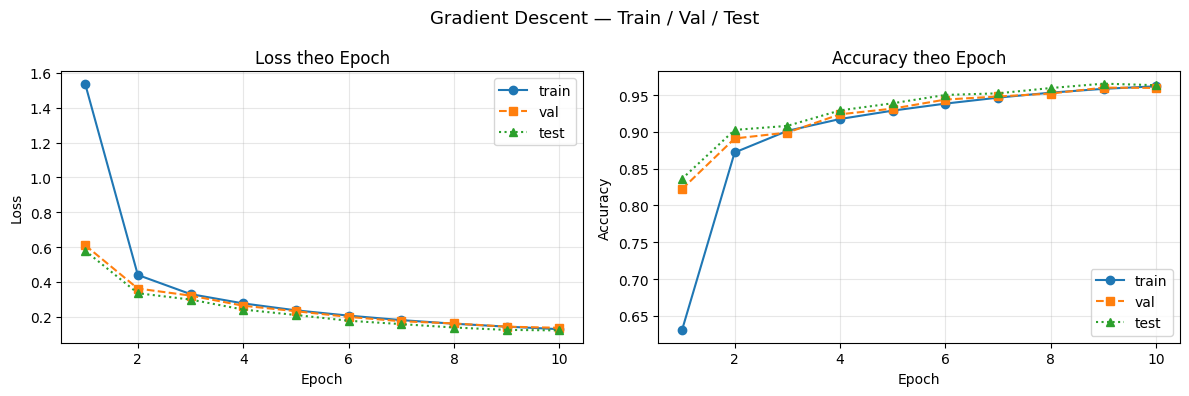

In [7]:
print(f"[Gradient] Accuracy cuối cùng — val: {history_grad['val_acc'][-1]*100:.2f}%  |  test: {history_grad['test_acc'][-1]*100:.2f}%")

epoch_axis = range(1, epochs_grad + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Gradient Descent — Train / Val / Test", fontsize=13)

# --- Biểu đồ Loss ---
axes[0].plot(epoch_axis, history_grad["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis, history_grad["val_loss"],   marker="s", label="val",  linestyle="--")
axes[0].plot(epoch_axis, history_grad["test_loss"],  marker="^", label="test", linestyle=":")
axes[0].set_title("Loss theo Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biểu đồ Accuracy ---
axes[1].plot(epoch_axis, history_grad["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis, history_grad["val_acc"],   marker="s", label="val",  linestyle="--")
axes[1].plot(epoch_axis, history_grad["test_acc"],  marker="^", label="test", linestyle=":")
axes[1].set_title("Accuracy theo Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Cập nhật tham số bằng Phương pháp Parabol (không dùng backward)

---

### Ý tưởng: tối ưu theo hướng 1 chiều

Thay vì tính $\nabla_\theta L_B$ (cần backward), ta cố định một **hướng ngẫu nhiên** $d_t$ và tìm bước nhảy tối ưu $\alpha^*$ trên đường thẳng:

$$
\phi(\alpha) = L_B(\theta_t + \alpha \, d_t), \quad \alpha \in \mathbb{R}
$$

---

### `normalize_direction(direction)` — Chuẩn hóa hướng

Sinh hướng ngẫu nhiên rồi chia cho norm để có **unit vector**:

$$
d_t \sim \mathcal{N}(0, I), \qquad d_t \leftarrow \frac{d_t}{\|d_t\|_2}
$$

Sau chuẩn hóa: $\|d_t\|_2 = 1$ → `delta` có đơn vị nhất quán ở mọi layer.

---

### `set_params(params, base_params, direction, alpha)` — Dịch chuyển tham số

$$
\theta = \theta_{\text{base}} + \alpha \cdot d_t
$$

Trong code: `p.copy_(b + alpha * d)` với $\alpha \in \{-\delta, 0, +\delta\}$.

---

### `parabolic_alpha(loss_minus, loss_zero, loss_plus, delta, alpha_clip)` — Tìm $\alpha^*$

Lấy 3 điểm loss tại $\alpha = -\delta, 0, +\delta$:

$$
L_- = \phi(-\delta), \quad L_0 = \phi(0), \quad L_+ = \phi(+\delta)
$$

Nội suy parabol $q(\alpha) = a\alpha^2 + b\alpha + c$ qua 3 điểm, giải hệ phương trình:

$$
c = L_0
$$

$$
a = \frac{L_- + L_+ - 2L_0}{2\delta^2} \quad \text{(độ cong — curvature)}
$$

$$
b = \frac{L_+ - L_-}{2\delta} \quad \text{(độ dốc tại } \alpha=0\text{)}
$$

Cực tiểu parabol (điều kiện $a > 0$):

$$
\alpha^* = -\frac{b}{2a} = \frac{\delta \,(L_- - L_+)}{2\,(L_- - 2L_0 + L_+)}
$$

Tiếp theo giới hạn: $\alpha^* \leftarrow \text{clip}(\alpha^*, -\alpha_{\max}, +\alpha_{\max})$ với `alpha_clip = 0.05`.

**Trường hợp đặc biệt** (`denom ≤ 1e-12`, parabol không mở lên): fallback chọn $\alpha \in \{-\delta, 0, +\delta\}$ có $L$ nhỏ nhất.

---

### Cập nhật tham số cuối cùng

$$
\theta_{t+1} = \theta_t + \alpha^* \cdot d_t
$$

**Chi phí tính toán:** 3 lần `model(x)` để lấy $L_-, L_0, L_+$ + 1 lần để tính metric sau cập nhật = **4 forward/batch** (so với 1 forward + 1 backward của Gradient Descent).


In [ ]:
def trainable_params(model):
    """Trả về danh sách các tham số cần huấn luyện (requires_grad=True)."""
    return [p for p in model.parameters() if p.requires_grad]


@torch.no_grad()
def set_params(params, base_params, direction, alpha):
    """
    Dịch chuyển tham số mô hình theo hướng direction với độ lớn alpha.

    Công thức: θ = θ_base + alpha × d
        - base_params: tham số gốc trước khi dịch chuyển (snapshot)
        - direction  : hướng ngẫu nhiên đã chuẩn hóa
        - alpha      : scalar, độ lớn bước dịch chuyển

    @torch.no_grad(): không tạo computation graph → nhanh hơn khi chỉ gán giá trị.
    """
    for p, b, d in zip(params, base_params, direction):
        p.copy_(b + alpha * d)


def normalize_direction(direction):
    """
    Chuẩn hóa hướng ngẫu nhiên về độ dài = 1 (unit vector).

    Tại sao cần chuẩn hóa?
    → Nếu không chuẩn hóa, delta có đơn vị khác nhau ở mỗi layer
      (layer lớn có norm lớn hơn → ảnh hưởng nhiều hơn không công bằng).
    → Sau khi chuẩn hóa: delta luôn có nghĩa thực sự là "bước dài delta" trong không gian tham số.

    Công thức: d_normalized = d / ||d||
    """
    sq_norm = torch.tensor(0.0, device=direction[0].device)
    for d in direction:
        sq_norm += (d * d).sum()    # tính bình phương norm
    norm = torch.sqrt(sq_norm).item()
    norm = max(norm, 1e-12)         # tránh chia cho 0
    return [d / norm for d in direction]


def parabolic_alpha(loss_minus, loss_zero, loss_plus, delta, alpha_clip):
    """
    Tính alpha tối ưu bằng nội suy parabol từ 3 điểm loss.

    Xấp xỉ: L(α) ≈ aα² + bα + c  (parabol theo hướng d)

    Giải hệ 3 phương trình tại α = -δ, 0, +δ:
        c = L(0)
        a = [L(-δ) + L(+δ) - 2L(0)] / (2δ²)   ← độ cong (curvature)
        b = [L(+δ) - L(-δ)]        / (2δ)      ← độ dốc  (slope)

    Cực tiểu của parabol tại:
        α* = -b / (2a) = δ × [L(-δ) - L(+δ)] / [2 × (L(-δ) - 2L(0) + L(+δ))]

    Trường hợp đặc biệt (denom ≤ 0):
        → Parabol mở xuống hoặc thẳng → không có cực tiểu hữu ích
        → Chọn điểm có loss nhỏ nhất trong 3 điểm (-δ, 0, +δ)

    alpha_clip: giới hạn |α*| ≤ alpha_clip để tránh bước nhảy quá lớn
    """
    # Mẫu số: 2a × δ² (xem công thức trên)
    denom = loss_minus - 2.0 * loss_zero + loss_plus  # tỉ lệ với hệ số a

    if denom > 1e-12:
        # Parabol mở lên (a > 0) → có cực tiểu → tính α* chính xác
        alpha_star = delta * (loss_minus - loss_plus) / (2.0 * denom)
    else:
        # Parabol phẳng hoặc mở xuống → fallback: chọn điểm thấp nhất trong 3
        candidates = [(-delta, loss_minus), (0.0, loss_zero), (delta, loss_plus)]
        alpha_star = min(candidates, key=lambda t: t[1])[0]

    # Cắt bỏ bước quá lớn để ổn định huấn luyện
    alpha_star = float(np.clip(alpha_star, -alpha_clip, alpha_clip))
    return alpha_star


def train_one_epoch_parabola(model, loader, loss_fn, delta=0.02, alpha_clip=0.05, max_batches=None):
    """
    Huấn luyện 1 epoch với phương pháp Parabol (không dùng backward).

    Luồng xử lý mỗi mini-batch:
    ┌──────────────────────────────────────────────────────────────────┐
    │ 1. Snapshot tham số hiện tại: base_params = θ                   │
    │ 2. Tạo hướng ngẫu nhiên d (chuẩn hóa ||d||=1)                  │
    │ 3. Tính L(θ − δd) → loss_minus                                  │
    │ 4. Tính L(θ)      → loss_zero    (khôi phục về base)            │
    │ 5. Tính L(θ + δd) → loss_plus                                   │
    │ 6. Nội suy parabol → tìm α* = argmin L(α)                       │
    │ 7. Cập nhật: θ ← θ_base + α* × d                               │
    └──────────────────────────────────────────────────────────────────┘

    Tham số:
        delta     : độ lệch để lấy 3 điểm (nhỏ → xấp xỉ tốt, lớn → khám phá rộng)
        alpha_clip: giới hạn bước cập nhật tối đa
        max_batches: giới hạn số batch/epoch (None = dùng hết)

    Chi phí tính toán: 3 lần forward thay vì 1 lần (chậm hơn ~3×)
    Bù lại: không cần backward, không cần tính gradient
    """
    model.train()
    params = trainable_params(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            # Bước 1: Chụp snapshot tham số gốc
            base_params = [p.detach().clone() for p in params]

            # Bước 2: Tạo hướng ngẫu nhiên và chuẩn hóa về unit vector
            direction = [torch.randn_like(p) for p in params]
            direction = normalize_direction(direction)

            # Bước 3: Tính loss tại θ − δd
            set_params(params, base_params, direction, -delta)
            loss_minus = loss_fn(model(x), y).item()

            # Bước 4: Tính loss tại θ (vị trí gốc)
            set_params(params, base_params, direction, 0.0)
            loss_zero = loss_fn(model(x), y).item()

            # Bước 5: Tính loss tại θ + δd
            set_params(params, base_params, direction, +delta)
            loss_plus = loss_fn(model(x), y).item()

            # Bước 6: Tìm α* tối ưu bằng nội suy parabol
            alpha = parabolic_alpha(loss_minus, loss_zero, loss_plus, delta, alpha_clip)

            # Bước 7: Cập nhật tham số về vị trí tối ưu θ_base + α* × d
            set_params(params, base_params, direction, alpha)

            # Đo loss sau khi cập nhật để ghi log
            logits = model(x)
            loss_after = loss_fn(logits, y)

        total_loss    += loss_after.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN — Phương pháp Parabol

**Quy trình 1 mini-batch** (không có `loss.backward()`):

$$
\underbrace{\theta_{\text{base}} = \theta_t}_{\text{snapshot}} \;\to\; \underbrace{d_t \sim \mathcal{N}(0,I),\; \|d_t\|=1}_{\text{hướng ngẫu nhiên}} \;\to\; \underbrace{L_-,\, L_0,\, L_+}_{\text{3 lần forward}} \;\to\; \underbrace{\alpha^* = \frac{\delta(L_- - L_+)}{2(L_- - 2L_0 + L_+)}}_{\text{nội suy parabol}} \;\to\; \underbrace{\theta_{t+1} = \theta_t + \alpha^* d_t}_{\text{cập nhật}}
$$

**Siêu tham số trong code:**
- `delta = 0.02`: khoảng thăm dò $\delta$ — phạm vi lấy 3 điểm $[-0.02, 0, +0.02]$ trong không gian tham số
- `alpha_clip = 0.05`: giới hạn $|\alpha^*| \leq 0.05$ — tránh bước nhảy quá lớn làm loss tăng đột ngột
- `epochs_para = 20`: dùng nhiều epoch hơn Gradient Descent vì mỗi bước chỉ tối ưu **1 hướng ngẫu nhiên** thay vì toàn bộ gradient

**Số lần forward mỗi epoch:**
$$
\underbrace{211}_{\text{batch/epoch}} \times \underbrace{4}_{\text{forward/batch}} = 844 \text{ lần forward} \quad (\text{so với } 211 \text{ của Gradient Descent})
$$


In [9]:
model_para    = SimpleCNN().to(device)
loss_fn_para  = cross_entropy_from_logits

# Lưu lịch sử 3 split: train / val / test
history_para = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "test_loss":  [], "test_acc":  [],
}

epochs_para = 20   # dùng nhiều epoch hơn vì parabol hội tụ chậm hơn

for epoch in range(1, epochs_para + 1):

    # --- Huấn luyện trên tập train bằng phương pháp parabol ---
    # Mỗi batch: 3 lần forward (không có backward) để nội suy parabol
    train_loss, train_acc = train_one_epoch_parabola(
        model_para,
        parabola_train_loader,
        loss_fn_para,
        delta=0.02,       # độ lệch lấy 3 điểm: δ = 0.02 (theo đơn vị của ||tham số||)
        alpha_clip=0.05,  # giới hạn bước: |α*| ≤ 0.05 để tránh bước quá lớn gây mất ổn định
        max_batches=None, # dùng toàn bộ train (54,000 mẫu)
    )

    # --- Đánh giá trên tập validation (KHÔNG cập nhật tham số) ---
    val_loss, val_acc = evaluate(model_para, parabola_val_loader, loss_fn_para)

    # --- Đánh giá trên tập test ---
    test_loss, test_acc = evaluate(model_para, test_loader, loss_fn_para)

    # Lưu lịch sử
    history_para["train_loss"].append(train_loss)
    history_para["train_acc"].append(train_acc)
    history_para["val_loss"].append(val_loss)
    history_para["val_acc"].append(val_acc)
    history_para["test_loss"].append(test_loss)
    history_para["test_acc"].append(test_acc)

    print(
        f"[Parabola] Epoch {epoch:2d}/{epochs_para} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Parabola] Epoch  1/20 | train_loss=2.3035, train_acc=0.0791 | val_loss=2.2986, val_acc=0.0953 | test_loss=2.3002, test_acc=0.0957
[Parabola] Epoch  2/20 | train_loss=2.2978, train_acc=0.0971 | val_loss=2.2931, val_acc=0.1088 | test_loss=2.2946, test_acc=0.1129
[Parabola] Epoch  3/20 | train_loss=2.2925, train_acc=0.1104 | val_loss=2.2880, val_acc=0.1210 | test_loss=2.2892, test_acc=0.1214
[Parabola] Epoch  4/20 | train_loss=2.2864, train_acc=0.1265 | val_loss=2.2820, val_acc=0.1393 | test_loss=2.2830, test_acc=0.1385
[Parabola] Epoch  5/20 | train_loss=2.2802, train_acc=0.1425 | val_loss=2.2756, val_acc=0.1662 | test_loss=2.2765, test_acc=0.1642
[Parabola] Epoch  6/20 | train_loss=2.2737, train_acc=0.1726 | val_loss=2.2687, val_acc=0.1895 | test_loss=2.2696, test_acc=0.1810
[Parabola] Epoch  7/20 | train_loss=2.2672, train_acc=0.1889 | val_loss=2.2621, val_acc=0.2152 | test_loss=2.2629, test_acc=0.2076
[Parabola] Epoch  8/20 | train_loss=2.2605, train_acc=0.2139 | val_loss=2.2549, val

## Trực quan hóa kết quả — Phương pháp Parabol

Vẽ 3 đường (train / val / test) tương tự Gradient Descent.

**Đặc điểm kỳ vọng của phương pháp Parabol:**
- Loss giảm **chậm hơn** và **dao động nhiều hơn** so với Gradient Descent
- Nguyên nhân: mỗi bước chỉ tối ưu theo 1 hướng ngẫu nhiên $d_t$, không dùng thông tin gradient toàn cục
- Trung bình nhiều bước ngẫu nhiên mới tương đương di chuyển theo hướng gradient

**Đọc biểu đồ:**

$$
\text{Tốc độ hội tụ:} \quad \frac{\Delta L_{\text{Gradient}}}{\Delta \text{epoch}} \gg \frac{\Delta L_{\text{Parabol}}}{\Delta \text{epoch}}
$$

- Nếu val_acc tăng dần dù chậm → phương pháp Parabol **vẫn học được**, chỉ cần nhiều epoch hơn
- Khoảng cách `train_acc - val_acc` nhỏ → ít overfit hơn (do cập nhật nhỏ và ngẫu nhiên, ít bị "khớp" với train)


[Parabola] Accuracy cuối cùng — val: 48.40%  |  test: 48.83%


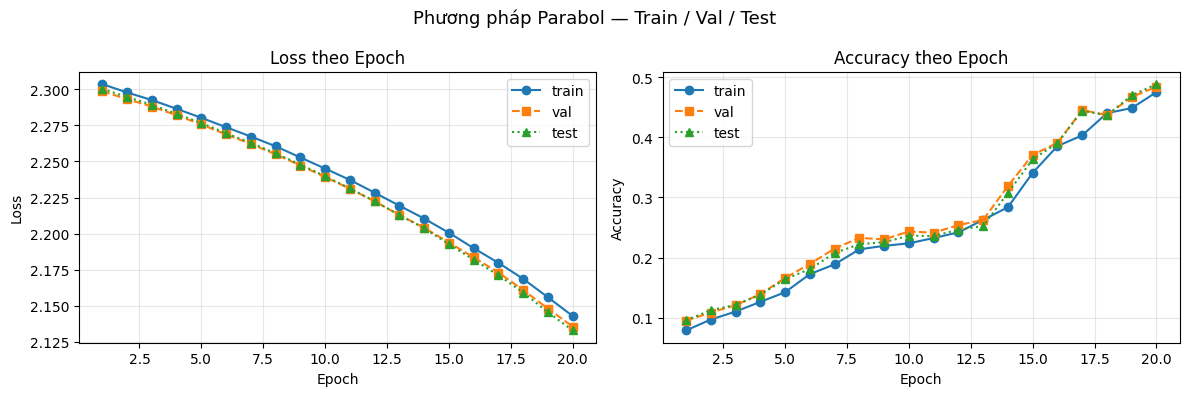

In [10]:
print(f"[Parabola] Accuracy cuối cùng — val: {history_para['val_acc'][-1]*100:.2f}%  |  test: {history_para['test_acc'][-1]*100:.2f}%")

epoch_axis_para = range(1, epochs_para + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Phương pháp Parabol — Train / Val / Test", fontsize=13)

# --- Biểu đồ Loss ---
axes[0].plot(epoch_axis_para, history_para["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis_para, history_para["val_loss"],   marker="s", label="val",  linestyle="--")
axes[0].plot(epoch_axis_para, history_para["test_loss"],  marker="^", label="test", linestyle=":")
axes[0].set_title("Loss theo Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biểu đồ Accuracy ---
axes[1].plot(epoch_axis_para, history_para["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis_para, history_para["val_acc"],   marker="s", label="val",  linestyle="--")
axes[1].plot(epoch_axis_para, history_para["test_acc"],  marker="^", label="test", linestyle=":")
axes[1].set_title("Accuracy theo Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## So sánh hai phương pháp — Bảng tổng hợp

| | Gradient Descent | Phương pháp Parabol |
|--|--|--|
| **Công thức cập nhật** | $\theta \leftarrow \theta - \eta \nabla_\theta L_B$ | $\theta \leftarrow \theta + \alpha^* d_t$ |
| **Nguồn thông tin** | Gradient $\nabla_\theta L_B$ (đạo hàm bậc 1) | 3 giá trị $L_-, L_0, L_+$ (zero-order) |
| **Cần `backward()`?** | **Có** — bắt buộc để tính $\partial L / \partial \theta$ | **Không** — chỉ cần `model(x)` |
| **Forward/batch** | 1 forward + 1 backward | 4 forward, 0 backward |
| **Hướng cập nhật** | Hướng gradient (tối ưu nhất tại điểm đó) | Hướng ngẫu nhiên $d_t \sim \mathcal{N}(0,I)$ |
| **Epochs** | 10 | 20 |

Bảng dưới tổng hợp **val acc** và **test acc** cuối cùng của cả hai — đây là 2 chỉ số quan trọng nhất vì đo trên dữ liệu **không tham gia cập nhật tham số**:


In [11]:
comparison = pd.DataFrame([
    {
        "Phương pháp"       : "Gradient Descent",
        "Train samples/epoch": len(train_loader.dataset),
        "Val samples/epoch"  : len(val_loader.dataset),
        "Epochs"             : epochs_grad,
        "Val loss cuối"      : round(history_grad["val_loss"][-1],  4),
        "Val acc (%) cuối"   : round(history_grad["val_acc"][-1]  * 100, 2),
        "Test loss cuối"     : round(history_grad["test_loss"][-1], 4),
        "Test acc (%) cuối"  : round(history_grad["test_acc"][-1] * 100, 2),
    },
    {
        "Phương pháp"       : "Parabol",
        "Train samples/epoch": len(parabola_train_loader.dataset),
        "Val samples/epoch"  : len(parabola_val_loader.dataset),
        "Epochs"             : epochs_para,
        "Val loss cuối"      : round(history_para["val_loss"][-1],  4),
        "Val acc (%) cuối"   : round(history_para["val_acc"][-1]  * 100, 2),
        "Test loss cuối"     : round(history_para["test_loss"][-1], 4),
        "Test acc (%) cuối"  : round(history_para["test_acc"][-1] * 100, 2),
    },
])

comparison


,Phương pháp,Train samples/epoch,Val samples/epoch,Epochs,Val loss cuối,Val acc (%) cuối,Test loss cuối,Test acc (%) cuối
0,Gradient Descent,54000,6000,10,0.1360,95.97,0.1212,96.33
1,Parabol,54000,6000,20,2.1355,48.40,2.1329,48.83


## Nhận xét & Kết luận

### Về chia dữ liệu
| Tập | Kích thước | Dùng trong công thức |
|-----|-----------|----------------------|
| Train | 54,000 | Tính $L_B$ để cập nhật $\theta$ mỗi batch |
| **Validation** | **6,000** | **Tính $L_{\text{val}}$ sau mỗi epoch — theo dõi overfitting, không cập nhật $\theta$** |
| Test | 10,000 | Tính $L_{\text{test}}$ sau cùng — đánh giá cuối, hoàn toàn độc lập |

---

### Phân tích kết quả thực nghiệm

| Phương pháp | Epochs | Val acc | Test acc | Val loss | Test loss |
|-------------|--------|---------|----------|----------|-----------|
| Gradient Descent | 10 | **95.97%** | **96.33%** | 0.1360 | 0.1212 |
| Parabol | 20 | 48.40% | 48.83% | 2.1355 | 2.1329 |

#### 1. Gradient Descent — hội tụ tốt, không overfit

Val acc = 95.97% ≈ Test acc = 96.33% → khoảng cách $\Delta = 0.36\%$ rất nhỏ:

$$
|{\text{val\_acc}} - \text{test\_acc}| = |95.97\% - 96.33\%| = 0.36\% \approx 0 \quad \Rightarrow \text{không overfit}
$$

Val loss = 0.1360 < Train loss ban đầu (~2.3) → mạng đã **học được đặc trưng thực sự**, không thuộc lòng train set.  
Test acc cao hơn val acc một chút là bình thường do tính ngẫu nhiên của split.

#### 2. Parabol — kết quả xấp xỉ random guessing

Với 10 lớp (chữ số 0–9), xác suất đoán ngẫu nhiên = $\frac{1}{10} = 10\%$.  
Val acc = 48.40% tuy cao hơn random nhưng **chỉ bằng ~½ so với Gradient Descent**.

Val loss = 2.1355 ≈ Test loss = 2.1329 → mạng **không overfit** nhưng cũng **không học được**:

$$
L \approx \log(10) \approx 2.303 \quad \text{(loss khi output đều nhau — mạng chưa học gì)}
$$

Loss = 2.13 ≈ 2.303 cho thấy mạng chỉ học được rất ít so với trạng thái khởi đầu ngẫu nhiên.

#### 3. Nguyên nhân Parabol kém hiệu quả

Mỗi bước cập nhật chỉ tối ưu **1 hướng ngẫu nhiên** $d_t$ trong không gian $P \approx 100{,}000$ chiều tham số:

$$
\text{Xác suất hướng ngẫu nhiên "gần" hướng gradient} \propto \frac{1}{\sqrt{P}} \approx \frac{1}{316} \approx 0.3\%
$$

→ Phần lớn các bước đi theo hướng ít hữu ích → cần **rất nhiều epoch hơn** để hội tụ (hàng trăm epoch thay vì 20).

Ngoài ra, với `delta = 0.02` và `alpha_clip = 0.05`, biên độ cập nhật tối đa mỗi bước là $|\alpha^*| \leq 0.05$ — rất nhỏ so với độ lớn cần thiết để di chuyển $\theta$ về vùng tối ưu.

---

### Về Gradient Descent

Mỗi bước sử dụng **toàn bộ thông tin gradient**:

$$
\theta_{t+1} = \theta_t - \underbrace{0.01}_{\eta} \cdot \underbrace{\nabla_\theta L_B(\theta_t)}_{\text{tính qua chain rule}}
$$

Backpropagation tính $\nabla_\theta L_B$ hiệu quả nhờ tái sử dụng đại lượng trung gian (1 backward = gradient tất cả tham số).

---

### Về Phương pháp Parabol

Mỗi bước dùng **nội suy bậc 2 theo 1 hướng ngẫu nhiên**:

$$
\alpha^* = \frac{\delta(L_- - L_+)}{2(L_- - 2L_0 + L_+)}, \qquad \theta_{t+1} = \theta_t + \alpha^* d_t
$$

Không cần đạo hàm → phù hợp cho hàm loss **không khả vi**, nhưng chi phí mỗi bước cao hơn (~4× forward) và hội tụ chậm hơn.

---

### Kết luận chính

| Tiêu chí | Gradient Descent | Parabol |
|----------|-----------------|---------|
| Test acc sau thực nghiệm | **96.33%** | 48.83% |
| Số epoch đến hội tụ | **10** | >20 (chưa hội tụ) |
| Chi phí mỗi epoch | 1× forward + 1× backward | 4× forward |
| Cần `loss.backward()`? | **Có** | Không |
| Phù hợp thực tế? | **Có** | Nghiên cứu/giảng dạy |

> **Kết luận:** Với mạng CNN và bộ dữ liệu MNIST, **Gradient Descent vượt trội hoàn toàn** so với Phương pháp Parabol (96.33% vs 48.83%).  
> Phương pháp Parabol có giá trị học thuật để minh họa tối ưu hóa **không cần đạo hàm** (zero-order optimization), nhưng không thực tế cho mạng có số chiều tham số lớn ($P \gg 1$).
